                              **   TTTLE**

# Predictive Analysis Using Machine Learning

## House Price Prediction Using Linear Regression




### Objective
The objective of this project is to build a Machine Learning model to predict house prices using Linear Regression. The project includes data cleaning, feature selection, model training, evaluation, and visualization.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("ZIP Extracted Successfully!")

ZIP Extracted Successfully!


In [3]:
import os

os.listdir()

['.config', 'Housing.csv', 'archive.zip', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## Step 1: Data Cleaning


In [7]:
# Check missing values
print(df.isnull().sum())

# Remove missing values (if any)
df = df.dropna()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Step 2: Feature Selection


In [8]:
# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

# Features (X) and Target (y)
X = df.drop("price", axis=1)
y = df["price"]

print(X.head())

   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  7420         4          2        3        2          True          False   
1  8960         4          4        4        3          True          False   
2  9960         3          2        2        2          True          False   
3  7500         4          2        2        3          True          False   
4  7420         4          1        2        2          True           True   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0         False                False                 True          True   
1         False                False                 True         False   
2          True                False                False          True   
3          True                False                 True          True   
4          True                False                 True         False   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0      

## Step 3: Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 4: Model Training

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Step 5: Model Evaluation


In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 970043.4039201636
R2 Score: 0.6529242642153184


## Data Visualization: Area vs Price

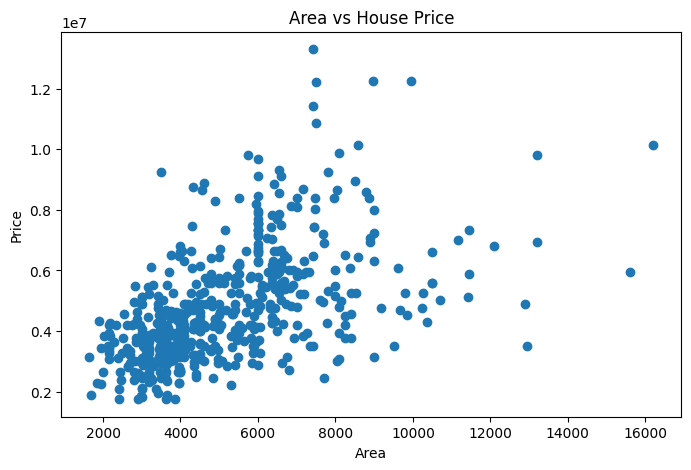

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["area"], df["price"])
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## Average House Price by Number of Bedrooms

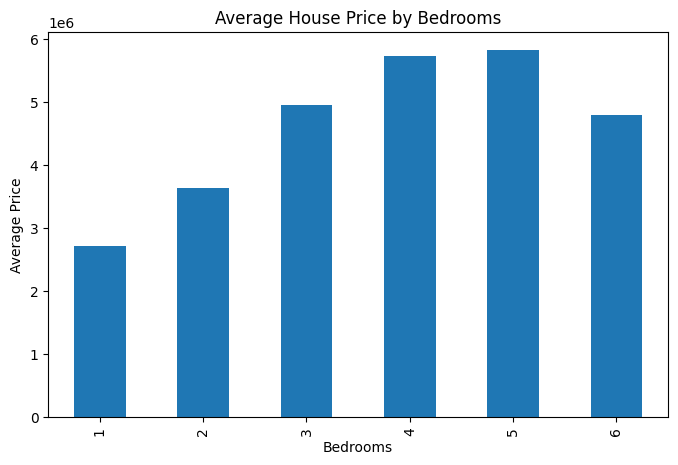

In [13]:
avg_price = df.groupby("bedrooms")["price"].mean()

plt.figure(figsize=(8,5))
avg_price.plot(kind="bar")
plt.title("Average House Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.show()

## Furnishing Status Distribution

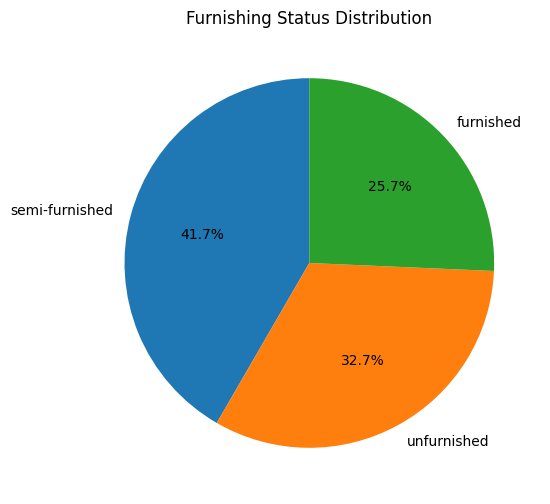

In [15]:
df2 = pd.read_csv("Housing.csv")

status = df2["furnishingstatus"].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(status, labels=status.index, autopct="%1.1f%%", startangle=90)
plt.title("Furnishing Status Distribution")
plt.show()

# Conclusion

In this project, a Machine Learning model was developed to predict house prices using Linear Regression.

The dataset was cleaned, categorical features were converted into numerical values, and relevant features were selected for model training. The data was divided into training and testing sets.

The model was evaluated using Mean Absolute Error (MAE) and R² Score. The model achieved an R² Score of **0.6529**, indicating satisfactory prediction performance.

Overall, this project successfully demonstrates data preprocessing, feature selection, model training, evaluation, and data visualization for predictive analysis.